# Figures
Genera todas las figuras del paper en formato publication-ready.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import os
os.makedirs('figures', exist_ok=True)

# ── Paleta y estilo publication-ready ────────────────────────────────────────
C = {
    'accepted':  '#2C6E8A',   # azul petróleo
    'rejected':  '#C0392B',   # rojo oscuro
    'oracle':    '#27AE60',   # verde
    'dtilde':    '#8E44AD',   # morado
    'neutral':   '#7F8C8D',   # gris
    'highlight': '#E67E22',   # naranja acento
}

plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         10,
    'axes.titlesize':    11,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linewidth':    0.5,
})

print('Setup OK')

Setup OK


In [2]:
# ── Cargar datasets ───────────────────────────────────────────────────────────
df_acc    = pd.read_csv('data/accepted_labeled.csv')
df_rej    = pd.read_csv('data/rejected_truth.csv')       # con labels reales
df_oracle = pd.read_csv('data/oracle_population.csv')
df_tilde  = pd.read_csv('data/D_tilde.csv')
df_hold   = pd.read_csv('data/holdout_population.csv')

# Limpiar columnas administrativas
for df in [df_acc, df_rej, df_oracle, df_tilde, df_hold]:
    for c in ['split', 'Unnamed: 0']:
        if c in df.columns:
            df.drop(columns=c, inplace=True)

feat_cols = ['X1', 'X2', 'X3', 'X4']

print(f"Accepted : {len(df_acc):,}  | bad rate: {df_acc['y'].mean():.1%}")
print(f"Rejected : {len(df_rej):,}  | bad rate: {df_rej['y'].mean():.1%}")
print(f"Oracle   : {len(df_oracle):,} | bad rate: {df_oracle['y'].mean():.1%}")
print(f"D_tilde  : {len(df_tilde):,}  | bad rate: {df_tilde['y'].mean():.1%}")
print(f"Holdout  : {len(df_hold):,}   | bad rate: {df_hold['y'].mean():.1%}")

Accepted : 15,599  | bad rate: 23.2%
Rejected : 4,401  | bad rate: 53.1%
Oracle   : 20,000 | bad rate: 29.8%
D_tilde  : 12,646  | bad rate: 31.5%
Holdout  : 2,000   | bad rate: 29.1%


## Figure 1 — El problema: sampling bias
Bad rate por grupo + distribución de covariables

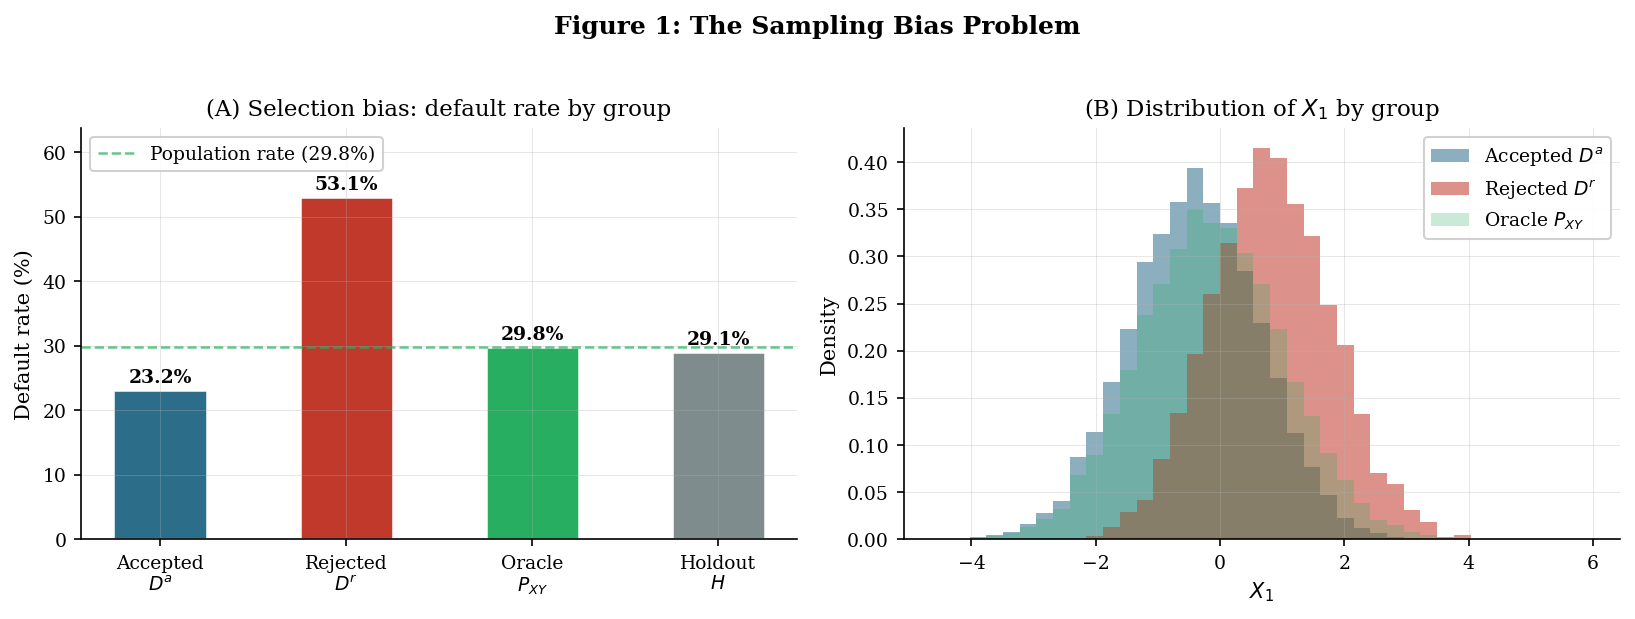

Fig 1 saved.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── Panel A: Bad rate por grupo ───────────────────────────────────────────────
ax = axes[0]
groups = ['Accepted\n$D^a$', 'Rejected\n$D^r$', 'Oracle\n$P_{XY}$', 'Holdout\n$H$']
rates  = [
    df_acc['y'].mean(),
    df_rej['y'].mean(),
    df_oracle['y'].mean(),
    df_hold['y'].mean(),
]
colors = [C['accepted'], C['rejected'], C['oracle'], C['neutral']]

bars = ax.bar(groups, [r * 100 for r in rates], color=colors,
              width=0.5, edgecolor='white', linewidth=1.2)

# Añadir etiquetas
for bar, r in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{r:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Línea de referencia: bad rate poblacional
pop_rate = df_oracle['y'].mean() * 100
ax.axhline(pop_rate, color=C['oracle'], ls='--', lw=1.2, alpha=0.7,
           label=f'Population rate ({pop_rate:.1f}%)')

ax.set_ylabel('Default rate (%)')
ax.set_title('(A) Selection bias: default rate by group')
ax.legend(loc='upper left', framealpha=0.9)
ax.set_ylim(0, max(rates) * 100 * 1.2)

# ── Panel B: Distribución de X1 por grupo ────────────────────────────────────
ax = axes[1]
bins = np.linspace(
    min(df_acc['X1'].min(), df_rej['X1'].min()),
    max(df_acc['X1'].max(), df_rej['X1'].max()),
    40
)

ax.hist(df_acc['X1'], bins=bins, density=True, alpha=0.55,
        color=C['accepted'], label='Accepted $D^a$')
ax.hist(df_rej['X1'], bins=bins, density=True, alpha=0.55,
        color=C['rejected'], label='Rejected $D^r$')
ax.hist(df_oracle['X1'], bins=bins, density=True, alpha=0.25,
        color=C['oracle'], label='Oracle $P_{XY}$')

ax.set_xlabel('$X_1$')
ax.set_ylabel('Density')
ax.set_title('(B) Distribution of $X_1$ by group')
ax.legend(framealpha=0.9)

fig.suptitle('Figure 1: The Sampling Bias Problem',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('figures/fig1_sampling_bias.pdf', bbox_inches='tight')
fig.savefig('figures/fig1_sampling_bias.png', bbox_inches='tight', dpi=200)
plt.show()
print('Fig 1 saved.')

## Figure 2 — Covariable shift: accepted vs rejected

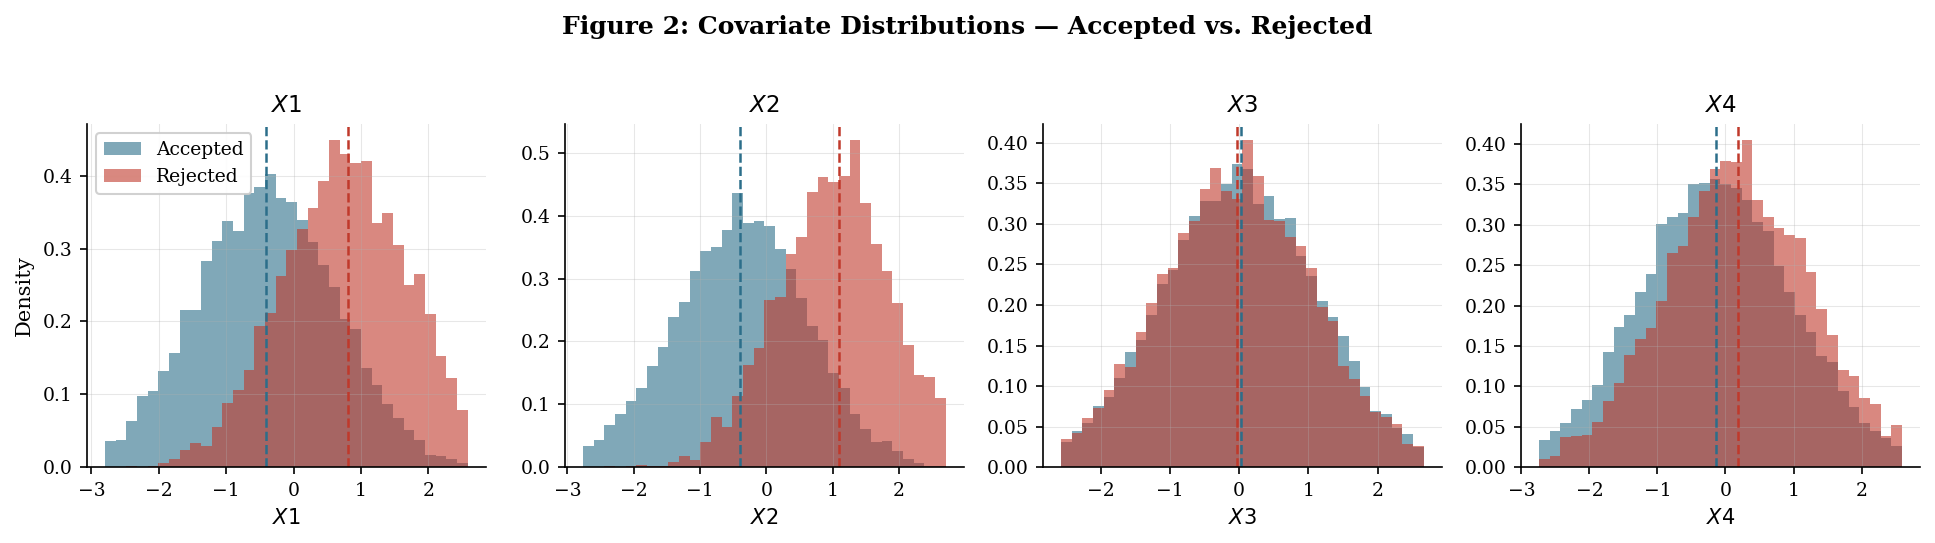

Fig 2 saved.


In [4]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))

for i, col in enumerate(feat_cols):
    ax = axes[i]
    all_vals = pd.concat([df_acc[col], df_rej[col]])
    bins = np.linspace(all_vals.quantile(0.01), all_vals.quantile(0.99), 35)

    ax.hist(df_acc[col], bins=bins, density=True, alpha=0.6,
            color=C['accepted'], label='Accepted')
    ax.hist(df_rej[col], bins=bins, density=True, alpha=0.6,
            color=C['rejected'], label='Rejected')

    # Medias
    ax.axvline(df_acc[col].mean(), color=C['accepted'], ls='--', lw=1.2)
    ax.axvline(df_rej[col].mean(), color=C['rejected'],  ls='--', lw=1.2)

    ax.set_xlabel(f'${col}$')
    ax.set_ylabel('Density' if i == 0 else '')
    ax.set_title(f'${col}$')
    if i == 0:
        ax.legend(framealpha=0.9)

fig.suptitle('Figure 2: Covariate Distributions — Accepted vs. Rejected',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('figures/fig2_covariate_shift.pdf', bbox_inches='tight')
fig.savefig('figures/fig2_covariate_shift.png', bbox_inches='tight', dpi=200)
plt.show()
print('Fig 2 saved.')

## Figure 3 — BASL: weak learner distribution sobre D^r

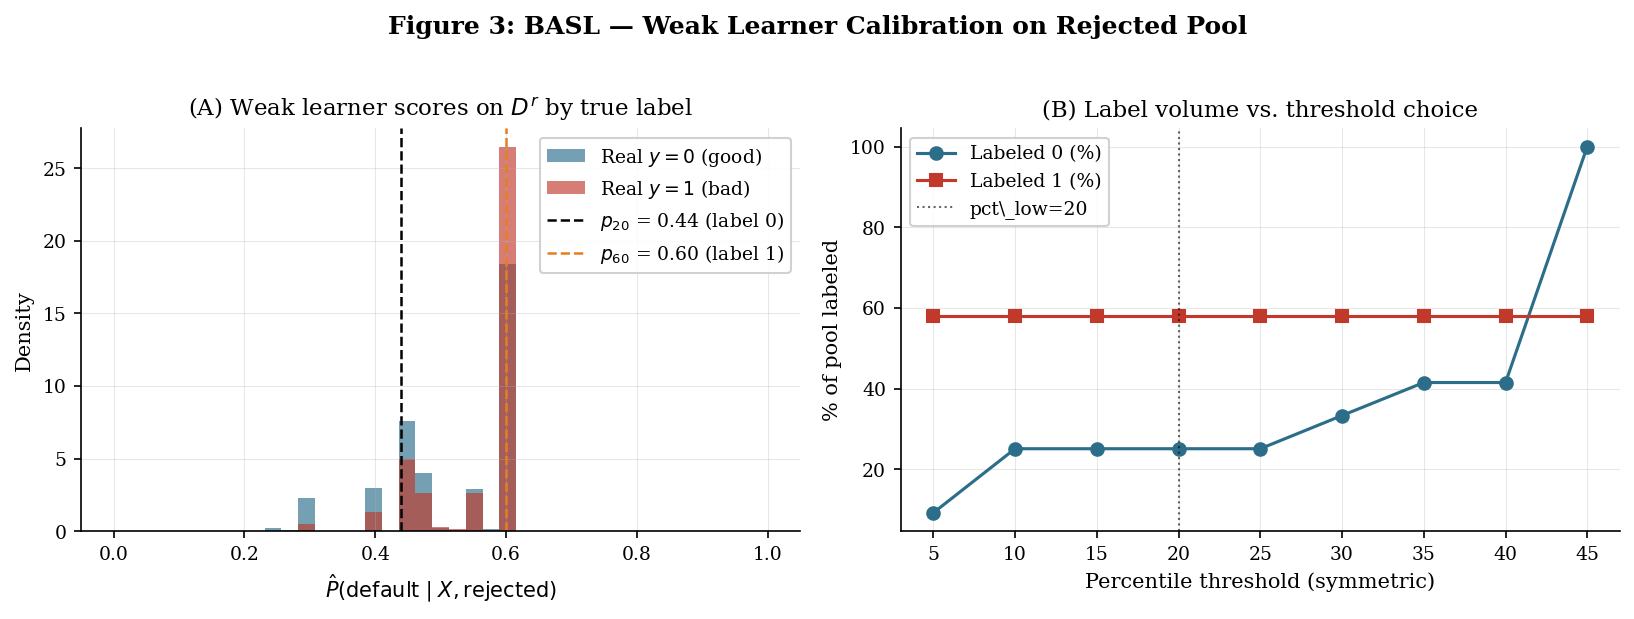

Fig 3 saved.


In [5]:
# Entrenar weak learner para diagnóstico
df_lbl = df_acc.copy()
# Necesita columna split — reconstruir
from sklearn.model_selection import train_test_split
idx = np.arange(len(df_lbl))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=df_lbl['y'])
idx_tr2, idx_ca = train_test_split(idx_tr, test_size=0.2, random_state=42,
                                    stratify=df_lbl.iloc[idx_tr]['y'])

X_tr = df_lbl.iloc[idx_tr2][feat_cols].values
y_tr = df_lbl.iloc[idx_tr2]['y'].values
X_ca = df_lbl.iloc[idx_ca][feat_cols].values
y_ca = df_lbl.iloc[idx_ca]['y'].values

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_ca_s = scaler.transform(X_ca)

weak = LogisticRegression(l1_ratio=0.5, penalty='elasticnet',
                           solver='saga', random_state=42, max_iter=5000)
X_comb = np.vstack([X_tr_s, X_ca_s])
y_comb = np.hstack([y_tr, y_ca])
cv = [(np.arange(len(X_tr_s)), np.arange(len(X_tr_s), len(X_comb)))]
cal = CalibratedClassifierCV(estimator=weak, method='isotonic', cv=cv)
cal.fit(X_comb, y_comb)

X_rej_s = scaler.transform(df_rej[feat_cols].values)
probs_r = cal.predict_proba(X_rej_s)[:, 1]
# Color por label real
y_rej_real = df_rej['y'].values

# ── Figura ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: distribución de probs por label real
ax = axes[0]
bins = np.linspace(0, 1, 40)
ax.hist(probs_r[y_rej_real == 0], bins=bins, density=True, alpha=0.65,
        color=C['accepted'], label='Real $y=0$ (good)')
ax.hist(probs_r[y_rej_real == 1], bins=bins, density=True, alpha=0.65,
        color=C['rejected'], label='Real $y=1$ (bad)')

pct_low  = np.percentile(probs_r, 20)
pct_high = np.percentile(probs_r, 60)
ax.axvline(pct_low,  color='black', ls='--', lw=1.2,
           label=f'$p_{{20}}$ = {pct_low:.2f} (label 0)')
ax.axvline(pct_high, color=C['highlight'], ls='--', lw=1.2,
           label=f'$p_{{60}}$ = {pct_high:.2f} (label 1)')

ax.set_xlabel('$\\hat{P}(\\text{default} \\mid X, \\text{rejected})$')
ax.set_ylabel('Density')
ax.set_title('(A) Weak learner scores on $D^r$ by true label')
ax.legend(framealpha=0.9)

# Panel B: % etiquetados como 0 y 1 según percentil threshold
ax = axes[1]
pcts = np.arange(5, 50, 5)
pct_zeros = []
pct_ones  = []
for p in pcts:
    cut_lo = np.percentile(probs_r, p)
    cut_hi = np.percentile(probs_r, 100 - p)
    pct_zeros.append((probs_r <= cut_lo).mean() * 100)
    pct_ones.append( (probs_r >= cut_hi).mean() * 100)

ax.plot(pcts, pct_zeros, 'o-', color=C['accepted'], label='Labeled 0 (%)')
ax.plot(pcts, pct_ones,  's-', color=C['rejected'],  label='Labeled 1 (%)')
ax.axvline(20, color='black', ls=':', lw=1, alpha=0.6, label='pct\_low=20')
ax.set_xlabel('Percentile threshold (symmetric)')
ax.set_ylabel('% of pool labeled')
ax.set_title('(B) Label volume vs. threshold choice')
ax.legend(framealpha=0.9)

fig.suptitle('Figure 3: BASL — Weak Learner Calibration on Rejected Pool',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('figures/fig3_weak_learner.pdf', bbox_inches='tight')
fig.savefig('figures/fig3_weak_learner.png', bbox_inches='tight', dpi=200)
plt.show()
print('Fig 3 saved.')

## Figure 4 — Dataset aumentado: recuperación de la distribución poblacional

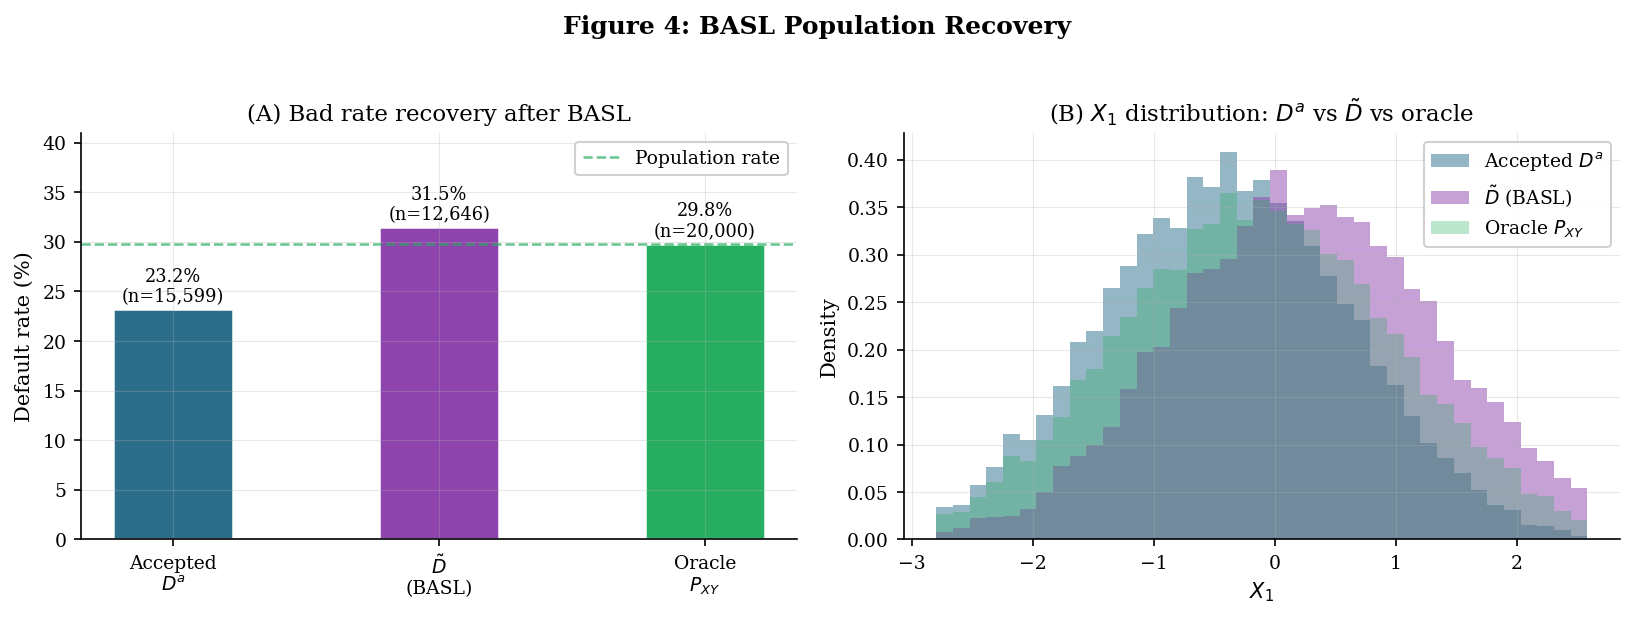

Fig 4 saved.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: bad rate por dataset
ax = axes[0]
labels  = ['Accepted\n$D^a$', '$\\tilde{D}$\n(BASL)', 'Oracle\n$P_{XY}$']
rates   = [df_acc['y'].mean(), df_tilde['y'].mean(), df_oracle['y'].mean()]
colors  = [C['accepted'], C['dtilde'], C['oracle']]
sizes   = [len(df_acc), len(df_tilde), len(df_oracle)]

bars = ax.bar(labels, [r * 100 for r in rates], color=colors,
              width=0.45, edgecolor='white', linewidth=1.2)
for bar, r, s in zip(bars, rates, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{r:.1%}\n(n={s:,})', ha='center', va='bottom', fontsize=8.5)

ax.axhline(df_oracle['y'].mean() * 100, color=C['oracle'],
           ls='--', lw=1.2, alpha=0.7, label='Population rate')
ax.set_ylabel('Default rate (%)')
ax.set_title('(A) Bad rate recovery after BASL')
ax.legend(framealpha=0.9)
ax.set_ylim(0, max(rates) * 100 * 1.3)

# Panel B: distribución de X1 en D^a vs D̃ vs oracle
ax = axes[1]
bins = np.linspace(
    df_oracle['X1'].quantile(0.01),
    df_oracle['X1'].quantile(0.99),
    40
)
ax.hist(df_acc['X1'],    bins=bins, density=True, alpha=0.5,
        color=C['accepted'], label='Accepted $D^a$')
ax.hist(df_tilde['X1'],  bins=bins, density=True, alpha=0.5,
        color=C['dtilde'],   label='$\\tilde{D}$ (BASL)')
ax.hist(df_oracle['X1'], bins=bins, density=True, alpha=0.3,
        color=C['oracle'],   label='Oracle $P_{XY}$')

ax.set_xlabel('$X_1$')
ax.set_ylabel('Density')
ax.set_title('(B) $X_1$ distribution: $D^a$ vs $\\tilde{D}$ vs oracle')
ax.legend(framealpha=0.9)

fig.suptitle('Figure 4: BASL Population Recovery',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig('figures/fig4_basl_recovery.pdf', bbox_inches='tight')
fig.savefig('figures/fig4_basl_recovery.png', bbox_inches='tight', dpi=200)
plt.show()
print('Fig 4 saved.')

## Figure 5 — Efecto causal: τ̂ con CI 95%

Requiere haber corrido `causal_effect.ipynb` primero.
Pega aquí los valores de τ̂ y SE de ambas estimaciones.

In [7]:
# ── Pega aquí los resultados de causal_effect.ipynb ───────────────────────────
# Formato: (tau_hat, standard_error)
results = {
    '$\\tilde{D}$ (BASL-expanded)': (None, None),   # ← reemplazar con tus valores
    'Accepted only $D^a$':           (None, None),   # ← reemplazar con tus valores
}

# Verificar que se llenaron los valores
if any(v[0] is None for v in results.values()):
    print("⚠ Reemplaza los None con tus valores de tau_hat y SE de causal_effect.ipynb")
else:
    fig, ax = plt.subplots(figsize=(7, 3.5))

    labels = list(results.keys())
    taus   = [results[l][0] for l in labels]
    ses    = [results[l][1] for l in labels]
    colors = [C['dtilde'], C['accepted']]

    y_pos = np.arange(len(labels))

    for i, (tau, se, color, label) in enumerate(zip(taus, ses, colors, labels)):
        ci_lo = tau - 1.96 * se
        ci_hi = tau + 1.96 * se
        ax.plot([ci_lo, ci_hi], [i, i], color=color, lw=2.5, solid_capstyle='round')
        ax.plot(tau, i, 'o', color=color, ms=8, zorder=5)
        ax.text(ci_hi + 0.002, i, f'$\\hat{{\\tau}}$ = {tau:+.4f}',
                va='center', ha='left', fontsize=9)

    ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Estimated PATE $\\hat{\\tau}$ (effect of $X_1$ on default)')
    ax.set_title('Figure 5: Causal Effect Estimates — BASL-expanded vs. Accepted Only\n'
                 '(Heckman Control Function + DR-AIPW, 95% CI)',
                 fontsize=10)
    ax.invert_yaxis()

    fig.tight_layout()
    fig.savefig('figures/fig5_causal_effect.pdf', bbox_inches='tight')
    fig.savefig('figures/fig5_causal_effect.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Fig 5 saved.')

⚠ Reemplaza los None con tus valores de tau_hat y SE de causal_effect.ipynb


## Figure 6 — Main figure: el mensaje completo en una figura

In [8]:
# Requiere los valores de tau/se de causal_effect.ipynb
tau_exp_val = None   # ← reemplazar
se_exp_val  = None
tau_acc_val = None
se_acc_val  = None

if tau_exp_val is None:
    print("⚠ Reemplaza los None con tus valores de causal_effect.ipynb")
else:
    fig = plt.figure(figsize=(13, 4.5))
    gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

    # ── Panel A: bad rate por grupo ───────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    groups = ['$D^a$', '$D^r$', '$P_{XY}$', '$\\tilde{D}$']
    rates  = [df_acc['y'].mean(), df_rej['y'].mean(),
              df_oracle['y'].mean(), df_tilde['y'].mean()]
    colors = [C['accepted'], C['rejected'], C['oracle'], C['dtilde']]

    bars = ax1.bar(groups, [r*100 for r in rates], color=colors,
                   width=0.5, edgecolor='white')
    for bar, r in zip(bars, rates):
        ax1.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.4,
                 f'{r:.0%}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax1.axhline(df_oracle['y'].mean()*100, color=C['oracle'],
                ls='--', lw=1, alpha=0.7)
    ax1.set_ylabel('Default rate (%)')
    ax1.set_title('(A) Selection bias')

    # ── Panel B: distribución X1 ──────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    bins = np.linspace(df_oracle['X1'].quantile(0.01),
                       df_oracle['X1'].quantile(0.99), 40)
    ax2.hist(df_acc['X1'],   bins=bins, density=True, alpha=0.55,
             color=C['accepted'], label='$D^a$')
    ax2.hist(df_tilde['X1'], bins=bins, density=True, alpha=0.55,
             color=C['dtilde'],   label='$\\tilde{D}$')
    ax2.hist(df_oracle['X1'], bins=bins, density=True, alpha=0.25,
             color=C['oracle'],  label='Oracle')
    ax2.set_xlabel('$X_1$'); ax2.set_ylabel('Density')
    ax2.set_title('(B) BASL population recovery')
    ax2.legend(framealpha=0.9, fontsize=8)

    # ── Panel C: coef plot τ̂ ─────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    res = [
        ('$\\tilde{D}$\n(BASL)', tau_exp_val, se_exp_val, C['dtilde']),
        ('$D^a$ only',           tau_acc_val, se_acc_val, C['accepted']),
    ]
    for i, (lbl, tau, se, color) in enumerate(res):
        ci_lo, ci_hi = tau - 1.96*se, tau + 1.96*se
        ax3.plot([ci_lo, ci_hi], [i, i], color=color, lw=3, solid_capstyle='round')
        ax3.plot(tau, i, 'o', color=color, ms=9, zorder=5)
        ax3.text(ci_hi + abs(tau)*0.05, i,
                 f'{tau:+.3f}', va='center', fontsize=9)
    ax3.axvline(0, color='black', lw=1, ls='--', alpha=0.5)
    ax3.set_yticks([0, 1])
    ax3.set_yticklabels(['$\\tilde{D}$\n(BASL)', '$D^a$ only'])
    ax3.set_xlabel('PATE $\\hat{\\tau}$')
    ax3.set_title('(C) Causal effect of $X_1$\n(Heckman + DR-AIPW)')
    ax3.invert_yaxis()

    fig.suptitle(
        'Sampling Bias in Credit Scoring: From Selection Bias to Causal Correction',
        fontsize=11, fontweight='bold', y=1.03
    )
    fig.savefig('figures/fig6_main.pdf', bbox_inches='tight')
    fig.savefig('figures/fig6_main.png', bbox_inches='tight', dpi=200)
    plt.show()
    print('Fig 6 (main) saved.')

⚠ Reemplaza los None con tus valores de causal_effect.ipynb


## Resumen de figuras

| Figura | Archivo | Mensaje |
|--------|---------|--------|
| 1 | `fig1_sampling_bias` | Bad rate por grupo + distribución X1 |
| 2 | `fig2_covariate_shift` | Shift en todas las covariables |
| 3 | `fig3_weak_learner` | Calibración del weak learner sobre D^r |
| 4 | `fig4_basl_recovery` | Recuperación de la distribución poblacional |
| 5 | `fig5_causal_effect` | τ̂ con CI 95% para D̃ vs accepted |
| 6 | `fig6_main` | Figura principal del paper (3 paneles) |